# ДЗ 4 Мультимодальные данные

Ситуация из ДЗ 3 развивается. Менеджер возвращается с конференции с горящими глазами и говорит:

"Слушай, моя идея не сработала потому, что мы кроме описания забыли визуальную составляющую. Учти картинки как-нибудь в ранжировании, тогда точно сможем сделать топ".

Отчаявшись доказывать, что рекомендательные системы работают не так, я пошёл переписывать парсер.

И теперь у нас есть картинки. Но что с ними делать?

In [12]:
import dill
from navec import Navec
from slovnet import NER

from natasha import (
    Segmenter,
    MorphVocab,

    NewsEmbedding,
    NewsMorphTagger,
    
    Doc
)

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

import math

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

import numpy as np

In [2]:
FULL_DF_PATH = "../artifacts/cian_dataset_with_images.dill"

In [3]:
with open(FULL_DF_PATH, "rb") as f:
    try:
        df = dill.load(f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

df.head()

,object_title,object_subtitle,jk_name,deadline,geo,price,meter_price,desc,img,idx
0,"2-комн. апартаменты, 173,3 м², 1/6 этаж",Секция Подъезд 1 • Сдача корпуса 3 кв. 2027,ЖК «Клубный дом Левенсон»,сдача ГК: 3 кв. 2027 года,"Москва, ЦАО, р-н Пресненский, м. Пушкинская, П...",467 910 000 ₽,2 700 000 ₽/м²,"Продаются апартаменты общей площадью 173,3 кв....",../artifacts/images\0_img.jpg,0.0
1,"Бизнес-класс. Гос.школа, парк","2-комн. квартира, 51,6 м², 2/59 этаж • Секция 5",ЖК «Мультиквартал VEER»,No_content,"Москва, ЗАО, р-н Можайский, м. Давыдково, Веер ЖК",No_content,422 800 ₽/м²,Старт продаж нового корпуса \n \nЖилой компле...,../artifacts/images\1_img.jpg,1.0
2,"2-комн. квартира, 86,1 м², 4/13 этаж",Секция 1 • Сдача корпуса 3 кв. 2027,ЖК «Клубный город-парк «Фрунзенская набережная»,сдача ГК: 3 кв. 2027 года,"Москва, ЦАО, р-н Хамовники, м. Фрунзенская, Фр...",233 470 000 ₽,2 711 614 ₽/м²,"Уютная квартира с двумя спальными комнатами, п...",../artifacts/images\2_img.jpg,2.0
3,1-комн квартира. Выдача ключей!,"1-комн. квартира, 39,09 м², 12/20 этаж",ЖК «FORST»,сдача ГК: 1 кв. 2025 года,"Москва, ЮАО, р-н Даниловский, м. Тульская, Авт...",17 916 902 ₽,458 350 ₽/м²,Выдача ключей! Квартира с отделкой White Box M...,../artifacts/images\3_img.jpg,3.0
4,"2-комн. апартаменты, 104,2 м², 5/9 этаж",Секция 1 • Сдан,ЖК «Vesper Tverskaya»,дом сдан,"Москва, ЦАО, р-н Тверской, м. Маяковская, 1-я ...",174 388 599 ₽,1 673 595 ₽/м²,Продаются апартаменты с сервисом 5* отеля на 5...,../artifacts/images\4_img.jpg,4.0


## Идея

Окей, у каждого объявления теперь есть картинка. Самый очевидный принцип совмещения мультимодальных данных - конкатенация эмбеддингов. Это сделать мы можем, однако, как притянуть такой сконкатенированный эмбеддинг в ранжирование?

Давайте переложим ответственность за хранимую информацию на машинное обучение:

1. Для текстов оставим всю ту предобработку, что была в ДЗ 3, только добавим нормализацию суммы TF-IDF.
2. Для картинок извлечём эмбеддинги какой-нить легковесной моделью, а потом, при помощи PCA схлопнем результат до прокси-ранга. Это значение также нормируем.
3. Соединим скоры с равными весами.
4. Определим ранги квантильным способом (биннигом)

### Текстовая модальность

In [6]:
# Это код ДЗ 3

dsc_list = df.desc.tolist()

navec = Navec.load('../artifacts/navec_news_v1_1B_250K_300d_100q.tar')
ner = NER.load('../artifacts/slovnet_ner_news_v1.tar')
ner.navec(navec)

dsc_ner = []

for elem in dsc_list:
    dsc_ner.append(ner(elem))

segmenter = Segmenter()
morph_vocab = MorphVocab()

emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

def extract_loc_tags(span_markup):
    loc_tags = []
    for span in span_markup.spans:
        if span.type == "LOC":
            loc_word = span_markup.text[span.start:span.stop]
            
            doc = Doc(loc_word)
        
            doc.segment(segmenter)
            
            doc.tag_morph(morph_tagger)
    
            for token in doc.tokens:
                token.lemmatize(morph_vocab)
            loc_tags.append(" ".join(token.lemma for token in doc.tokens))
    return {"text": span_markup.text, "tags": loc_tags}


dsc_tags = [extract_loc_tags(item) for item in dsc_ner]

docs_str = [' '.join(tags['tags']) for tags in dsc_tags]

vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), preprocessor=lambda x: x)
tfidf_matrix = vectorizer.fit_transform(docs_str)

feature_names = vectorizer.get_feature_names_out()
sum_tfidf = tfidf_matrix.sum(axis=1).A1

D:\projects\data_for_ML\venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [7]:
# немного колдовства с нормализацией

scaler_text = MinMaxScaler()
text_scores_norm = scaler_text.fit_transform(sum_tfidf.reshape(-1, 1)).flatten()


result_df = pd.DataFrame({'desc': [tags["text"] for tags in dsc_tags], 'tag': [tags["tags"] for tags in dsc_tags], 'text_scores_norm': text_scores_norm})
result_df.head()

,desc,tag,text_scores_norm
0,"Продаются апартаменты общей площадью 173,3 кв....","[патриарший пруд, патриарший пруд]",0.324435
1,Старт продаж нового корпуса \n \nЖилой компле...,"[москва, кутузовский проспект, москва, москва,...",0.694000
2,"Уютная квартира с двумя спальными комнатами, п...","[фрунзенский набережная, кремль, москва-река, ...",0.664059
3,Выдача ключей! Квартира с отделкой White Box M...,"[нептун, москва-река, даниловский рынок, тюфел...",0.569626
4,Продаются апартаменты с сервисом 5* отеля на 5...,"[триумфальный площадь, тверской улица, патриар...",0.639532


### Модальность картинок

In [10]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # средние значения для ImageNet
        std=[0.229, 0.224, 0.225]    # стандартные отклонения для ImageNet
    )
])

# удаляем классификационную голову, последние слои и переводим в режим .eval()
model = models.mobilenet_v2(pretrained=True)
model.classifier = nn.Identity()
model.eval() 

D:\projects\data_for_ML\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\projects\data_for_ML\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\realn/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [14]:
df['img'].describe()

count           1649
unique          1540
top       No_content
freq             110
Name: img, dtype: object

In [13]:
def extract_image_feature(image_path):
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Ошибка загрузки {image_path}: {e}")
        return np.zeros(1280)  # размер эмбеддинга MobileNet_v2
    input_tensor = preprocess(image).unsqueeze(0)  # добавляем batch размер 1
    with torch.no_grad():
        features = model(input_tensor)
    return features.squeeze().numpy()

image_embeddings = np.array([extract_image_feature(path) for path in df['img']])



Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory: 'No_content'
Ошибка загрузки No_content: [Errno 2] No such file or directory:

In [15]:
# У нас будет 110 нулевых векторов для объялений без картинок. Что ж, так тому и быть.
pca = PCA(n_components=1)
image_scores = pca.fit_transform(image_embeddings).flatten()

In [17]:
# Нормализуем веса

scaler_img = MinMaxScaler()
image_scores_norm = scaler_img.fit_transform(image_scores.reshape(-1, 1)).flatten()
result_df['image_score'] = image_scores_norm
result_df.head()

,desc,tag,text_scores_norm,image_score
0,"Продаются апартаменты общей площадью 173,3 кв....","[патриарший пруд, патриарший пруд]",0.324435,0.628224
1,Старт продаж нового корпуса \n \nЖилой компле...,"[москва, кутузовский проспект, москва, москва,...",0.694000,0.883832
2,"Уютная квартира с двумя спальными комнатами, п...","[фрунзенский набережная, кремль, москва-река, ...",0.664059,0.857610
3,Выдача ключей! Квартира с отделкой White Box M...,"[нептун, москва-река, даниловский рынок, тюфел...",0.569626,0.625182
4,Продаются апартаменты с сервисом 5* отеля на 5...,"[триумфальный площадь, тверской улица, патриар...",0.639532,0.724434


In [18]:
# Нормальное взвешивание

alpha = 0.5
combined_scores = alpha * text_scores_norm + (1 - alpha) * image_scores_norm
result_df['combined_score'] = combined_scores

In [19]:
# Биннинг по квантилям
quantiles = np.quantile(combined_scores, [0.2, 0.4, 0.6, 0.8])
def assign_rank(score):
    if score <= quantiles[0]:
        return 1
    elif score <= quantiles[1]:
        return 2
    elif score <= quantiles[2]:
        return 3
    elif score <= quantiles[3]:
        return 4
    else:
        return 5

result_df['rank'] = [assign_rank(s) for s in combined_scores]
result_df.head()

,desc,tag,text_scores_norm,image_score,combined_score,rank
0,"Продаются апартаменты общей площадью 173,3 кв....","[патриарший пруд, патриарший пруд]",0.324435,0.628224,0.476329,1
1,Старт продаж нового корпуса \n \nЖилой компле...,"[москва, кутузовский проспект, москва, москва,...",0.694000,0.883832,0.788916,5
2,"Уютная квартира с двумя спальными комнатами, п...","[фрунзенский набережная, кремль, москва-река, ...",0.664059,0.857610,0.760835,5
3,Выдача ключей! Квартира с отделкой White Box M...,"[нептун, москва-река, даниловский рынок, тюфел...",0.569626,0.625182,0.597404,3
4,Продаются апартаменты с сервисом 5* отеля на 5...,"[триумфальный площадь, тверской улица, патриар...",0.639532,0.724434,0.681983,4


In [20]:
DATASET_PATH = "../artifacts/multimodal_df.dill"

with open(DATASET_PATH, "wb") as f:
    try:
        dill.dump(result_df, f)
    except Exception as e:
        print(f"Ошибка загрузки существующих данных: {e}")

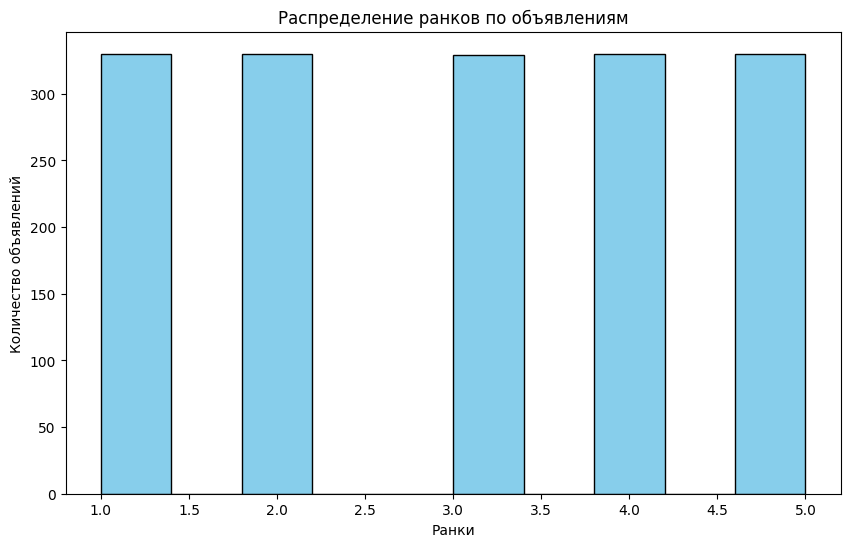

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(result_df['rank'], color='skyblue', edgecolor='black')
plt.xlabel('Ранки')
plt.ylabel('Количество объявлений')
plt.title('Распределение ранков по объявлениям')
plt.show()

## Выводы

Мы сделали равномерное разбиение на ранги, которое можно балансировать в зависимости от бизнес-потребности.

EDA не проводился, т.к. уже был проведён для текстов в ноутбуке HW_3, а для картинок нечего анализировать - мы переводим бинарники в эмбэддинги, а затем нормируем 1-компонентный PCA. 

В дальнейшем, датасет, собранный таким пайплайном, можно использовать на построении рекомендательной модели. Понятно, что большинство моделей также утилизируют признаки айтема и юзера. И если первые можно добавить и итоговый датасет безболезненно (они у нас есть), то вторые мы не парсили.